<a href="https://colab.research.google.com/github/01241008/lidya-moulina-08/blob/main/Analisis_Spektral_Data_Iklim_Hasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Spektral Data Iklim Berbasis Deret Waktu

## Anggota Kelompok

- Lidya Moulina 01241008

- Lodia Vrita Sari 01241009

- Umrotul Mafiroh 01241024

## Pendahuluan

Analisis spektral digunakan untuk mengidentifikasi pola periodik pada data deret waktu iklim menggunakan transformasi Fourier.

In [46]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

print("Library berhasil diimport")

Library berhasil diimport


# --- TASK 1: Load and plot the raw time-domain data ---

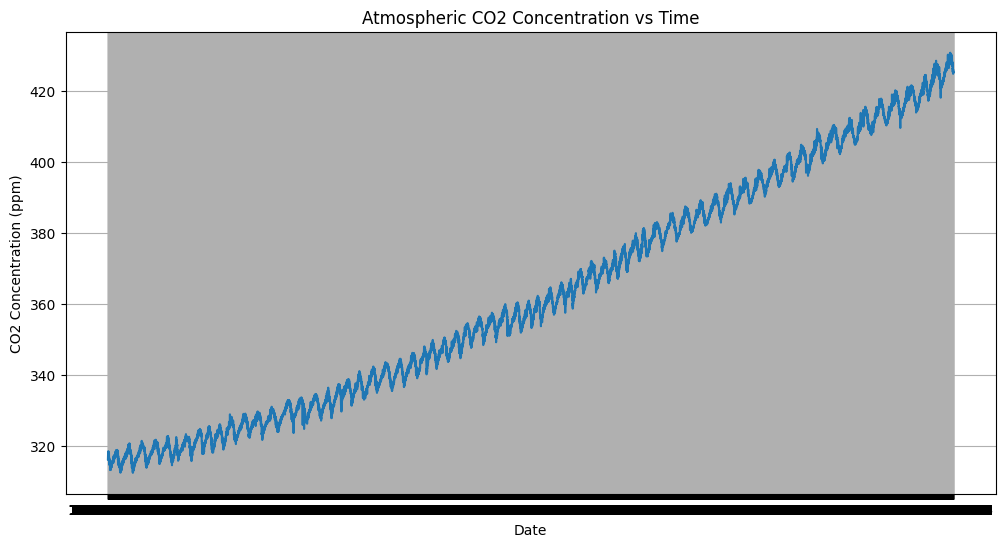

In [41]:
# Load dataset

data = pd.read_csv('co2-ppm-daily.csv')

# Extract columns

t = data['date']

co2 = data['value']

# Plot raw data

plt.figure(figsize=(12,6))

plt.plot(t, co2)

plt.xlabel('Date')

plt.ylabel('CO2 Concentration (ppm)')

plt.title('Atmospheric CO2 Concentration vs Time')

plt.grid(True)

plt.show()

# --- TASK 2: Detrend the signal ---

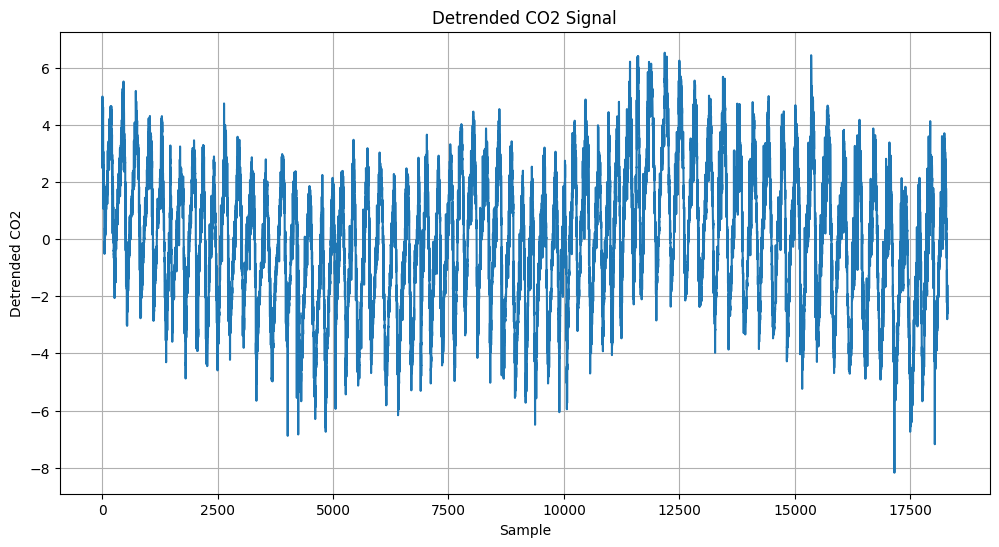

In [42]:
from numpy.polynomial import Polynomial

# Fit polynomial orde 2

p = Polynomial.fit(range(len(co2)), co2, 2)

# Hitung trend

trend = p(range(len(co2)))

# Detrend data

y_detrended = co2 - trend

# Plot hasil

plt.figure(figsize=(12,6))

plt.plot(y_detrended)

plt.xlabel('Sample')

plt.ylabel('Detrended CO2')

plt.title('Detrended CO2 Signal')

plt.grid(True)

plt.show()

# --- TASK 3: Compute the FFT and Power Spectrum ---


In [43]:
# Jumlah data

N = len(y_detrended)

# Selang waktu (harian)

dt = 1/365.25

# FFT

fft_values = np.fft.fft(y_detrended)

# Frekuensi

freq = np.fft.fftfreq(N, d=dt)

# Power spectrum (magnitudo)

power = np.abs(fft_values)

# Ambil frekuensi positif saja

positive = freq > 0

freq_pos = freq[positive]

power_pos = power[positive]

# --- TASK 4: Visualize the Frequency Domain ---

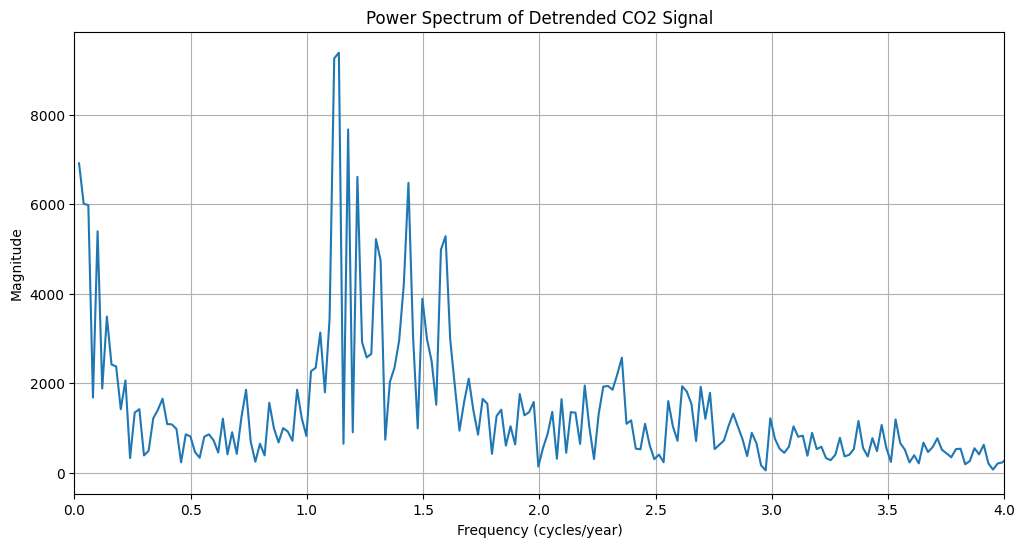

In [44]:
plt.figure(figsize=(12,6))

plt.plot(freq_pos, power_pos)

plt.xlabel('Frequency (cycles/year)')

plt.ylabel('Magnitude')

plt.title('Power Spectrum of Detrended CO2 Signal')

plt.xlim(0,4)

plt.grid(True)

plt.show()

# --- TASK 5: Programmatic peak detection ---


In [45]:
peak_idx = np.argmax(power_pos)

dominant_frequency = freq_pos[peak_idx]

period = 1 / dominant_frequency

print(f"Dominant Frequency = {dominant_frequency:.4f} cycles/year")

print(f"Dominant Period = {period:.4f} years")

Dominant Frequency = 1.1374 cycles/year
Dominant Period = 0.8792 years


Dominant Periodic Cycle: 0.8792 years.

Physical Interpretation:

Frekuensi dominan yang diperoleh dari analisis FFT adalah sekitar 1.1374 siklus per tahun, yang setara dengan periode sekitar 0.8792 tahun. Puncak frekuensi ini menunjukkan adanya variasi musiman konsentrasi CO₂ di atmosfer yang dipengaruhi oleh siklus pertumbuhan dan peluruhan vegetasi.

Pada musim pertumbuhan, tumbuhan menyerap CO₂ melalui fotosintesis sehingga konsentrasi CO₂ menurun. Sebaliknya, saat proses peluruhan dan dormansi, CO₂ dilepaskan kembali ke atmosfer sehingga menghasilkan pola periodik.

Proses detrending diperlukan untuk menghilangkan tren kenaikan jangka panjang konsentrasi CO₂. Tanpa detrending, spectral leakage akan menutupi sinyal musiman yang sebenarnya sehingga hasil analisis Fourier menjadi kurang akurat.

## Data Sources

1. Daily Atmospheric CO₂ Concentration Dataset

   https://github.com/datasets/co2-ppm-daily/blob/main/data/co2-ppm-daily.csv

## Penggunaan AI

Pada pengerjaan studi kasus ini, kami menggunakan beberapa alat AI sebagai berikut:

1. Claude
    * Digunakan untuk membantu mencari ide dan referensi judul studi kasus.
2. ChatGPT (OpenAI)
    * Digunakan untuk membantu memahami instruksi tugas, debugging kode Python, serta membantu interpretasi hasil analisis Fast Fourier Transform (FFT).
3. Dola AI
    * Digunakan untuk membantu penyusunan dan perapihan struktur laporan agar lebih sistematis dan mudah dipahami.

Seluruh AI digunakan sebagai alat bantu pembelajaran dan pendukung proses pengerjaan. Analisis data, pengujian program, interpretasi hasil, dan penyusunan laporan akhir tetap dilakukan oleh anggota kelompok.

## Penggunaan Aplikasi Lain

1. Google Colab
    * Digunakan untuk menjalankan kode Python dan melakukan analisis FFT.
2. GitHub
    * Digunakan untuk penyimpanan repository, kolaborasi kelompok, dan pengumpulan tugas.
3. Jupyter Notebook
    * Digunakan sebagai media penyusunan laporan yang menggabungkan kode program, visualisasi data, dan pembahasan hasil analisis.